# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [1]:
!pip install geemap


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "fast-archive-494108-e7"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate(force=True)
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota.  
You can adjust it later, but it is helpful to begin with a region dominated by large row-crop fields. In one scene, I want you to find a place that has:

- individual crop fields that you can isolate
- A city or town that we're not expecting a strong vegetative growth signal from
- a stand of trees you can isolate

**QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:**
The chosen Midwest subregion is ideal for exploring crop growth. Its fields are massive, flat, and perfectly aligned North to South. This regular geometry minimizes topographic distortions. It also removes row orientation variations. As a result, we can average pixels over large areas to increase the signal-to-noise ratio. Crops here will show massive seasonal variation. Early in the season, bare soil causes strong surface scattering. This results in higher VV and very low VH. Later, the growing canopy increases volume scattering. This causes a steep rise in VH backscatter and significantly changes the VV-VH ratio until harvest. In contrast, a stand of trees will show much less seasonal change. Trees have a permanent physical structure of trunks and branches. This causes strong volume scattering all year long. Therefore, their VH signal remains high and stable, even during winter. Finally, an isolated city or town is a static feature. Buildings act as "corner reflectors" that create a double-bounce effect. This produces extremely high, bright, and stable backscatter year-round, especially in VV. The city will show a flat time-series profile with zero vegetative growth signal.

In [4]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.95, 43.65, -93.25, 44.15])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
display(m)

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

\[
VV - VH
\]

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [5]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:**
The main advantage of using monthly median stacks is a massive reduction in radar speckle noise and the smoothing of short-term environmental anomalies (like a single heavy rainstorm that temporarily spikes soil moisture and backscatter). This creates a much cleaner, more reliable signal for observing long-term, slow-changing processes like seasonal crop growth. The disadvantage is the loss of temporal resolution; by collapsing a month of data into one image, you blur out the exact timing of rapid events. Therefore, you would not want to use temporal averaging when monitoring sudden, acute events where exact dates matter, such as mapping a rapid flood extent, detecting the precise day a forest was clear-cut, or monitoring a sudden landslide.

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:**
We must filter by these parameters to ensure we are comparing "apples to apples" over time, as radar backscatter is highly sensitive to the geometry and physical properties of the observation. If we mixed ascending (flying south-to-north, looking east) and descending (flying north-to-south, looking west) passes, the radar would view the exact same fields from opposite angles. Because row crops have directional structures (ridges and valleys), viewing them from different sides would produce wildly different backscatter values due to changing incidence angles and shadow effects. Mixing these passes would introduce massive, artificial geometric noise into the time series, making it impossible to isolate the actual biological growth signal of the crops.


In [7]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")


Monthly images in stack: 10
Month 02: 8 scenes
Month 03: 8 scenes
Month 04: 10 scenes
Month 05: 4 scenes
Month 06: 3 scenes
Month 07: 3 scenes
Month 08: 4 scenes
Month 09: 2 scenes
Month 10: 4 scenes
Month 11: 4 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER
When comparing February (bare soil/snow) to July (peak biomass), the VH polarization shows a much more dramatic increase in overall brightness across the agricultural fields than the VV polarization. This is expected because VH is highly sensitive to the volume scattering created by dense crop canopies in summer, whereas early-season bare fields return almost zero cross-polarized energy. For my ROIs, I will choose a bright, static urban area (like a town center) as my non-crop control, as it remains bright in both months. For the crops, I will select fields that are very dark in February but become extremely bright in July's VH image, indicating massive vegetative growth (likely tall crops like corn). To meet the extra challenge, I will look for a field that remains relatively dark or shows only a modest increase in July for my "short crop" or "left barren" ROI, as this indicates a lack of significant volume scattering compared to its neighbours.

In [13]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 7, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.
m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VH"), vh_vis, "VH July")
)
#m.addLayer(aoi, {"color": "red"}, "AOI")
display(m)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [14]:
#Plot the VV split_map here.

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [15]:
m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [16]:
drawn_fc = m.draw_features
print(drawn_fc)

[]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [19]:
field_1 = ee.Geometry.Rectangle([-93.731, 43.949, -93.714, 43.964])
field_2 = ee.Geometry.Rectangle([-93.666, 43.865, -93.646, 43.882])
field_3 = ee.Geometry.Rectangle([-93.600, 43.900, -93.580, 43.920])
trees_1 = ee.Geometry.Rectangle([-93.620, 43.950, -93.610, 43.960])
control_1 = ee.Geometry.Rectangle([-93.585, 43.971, -93.571, 43.982])

roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "Trees_1": trees_1,
    "Control_1": control_1
}

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
m

##PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
for name, roi in roi_dict.items():
    print(name, roi.getInfo())


Field_1 {'type': 'Polygon', 'coordinates': [[[-93.731, 43.949], [-93.714, 43.949], [-93.714, 43.964], [-93.731, 43.964], [-93.731, 43.949]]]}
Field_2 {'type': 'Polygon', 'coordinates': [[[-93.666, 43.865], [-93.646, 43.865], [-93.646, 43.882], [-93.666, 43.882], [-93.666, 43.865]]]}
Field_3 {'type': 'Polygon', 'coordinates': [[[-93.6, 43.9], [-93.58, 43.9], [-93.58, 43.92], [-93.6, 43.92], [-93.6, 43.9]]]}
Trees_1 {'type': 'Polygon', 'coordinates': [[[-93.62, 43.95], [-93.61, 43.95], [-93.61, 43.96], [-93.62, 43.96], [-93.62, 43.95]]]}
Control_1 {'type': 'Polygon', 'coordinates': [[[-93.585, 43.971], [-93.571, 43.971], [-93.571, 43.982], [-93.585, 43.982], [-93.585, 43.971]]]}


## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [20]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

ts_dict["Field_1"]


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-28.475619,-15.556043,12.919577,2025-02-01,2,8,2025
1,-21.902293,-11.903936,9.998357,2025-03-01,3,8,2025
2,-24.680078,-12.809517,11.870561,2025-04-01,4,10,2025
3,-25.603002,-13.727509,11.875493,2025-05-01,5,4,2025
4,-23.609002,-13.618245,9.990756,2025-06-01,6,3,2025
5,-16.466721,-9.960643,6.506078,2025-07-01,7,3,2025
6,-17.197871,-10.698048,6.499823,2025-08-01,8,4,2025
7,-17.231722,-10.388528,6.843194,2025-09-01,9,2,2025
8,-20.174754,-11.434853,8.739901,2025-10-01,10,4,2025
9,-22.192807,-11.679119,10.513688,2025-11-01,11,4,2025


**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**
Based on the data table, the minimum VH backscatter (-28.47) occurs in February (Month 2), while the maximum VH backscatter (-16.46) occurs in July (Month 7). Yes, this perfectly matches our expectations from the visual image comparison. February represents early-season conditions with bare soil or snow, resulting in almost zero volume scattering and the darkest pixels. Conversely, July represents peak growing season. The dense, tall crop canopy creates massive volume scattering, returning the highest amount of cross-polarized (VH) energy to the radar and producing the brightest pixels.

## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**
Qualitatively, the farms and trees show a pronounced seasonal curve typical of vegetation development, whereas the town (Control_1), while still showing some seasonal drift, tends to stand out as having slightly different dynamics, particularly in the VV-VH ratio. Based on the VH plot, crops start actively growing around May (when volume scattering begins to increase sharply), peak and stop growing around July/August (when the signal plateaus), and are harvested by October (indicated by the steep drop in backscatter back to bare-soil levels). The VV-VH ratio separates crops from the control AOI much better than VV alone; the VV-VH difference drops significantly during peak biomass for crops due to rising VH, creating a clearer distinction from the control. Control_1 looks the least like an actively growing crop field, displaying different temporal behavior. The fields (Field_1, Field_2, Field_3) show the strongest seasonal change in VH, which perfectly aligns with the massive seasonal development of crop volume scattering, whereas a true built-up area (like a town) should be the most stable through time, as physical structures do not undergo seasonal vegetative growth.

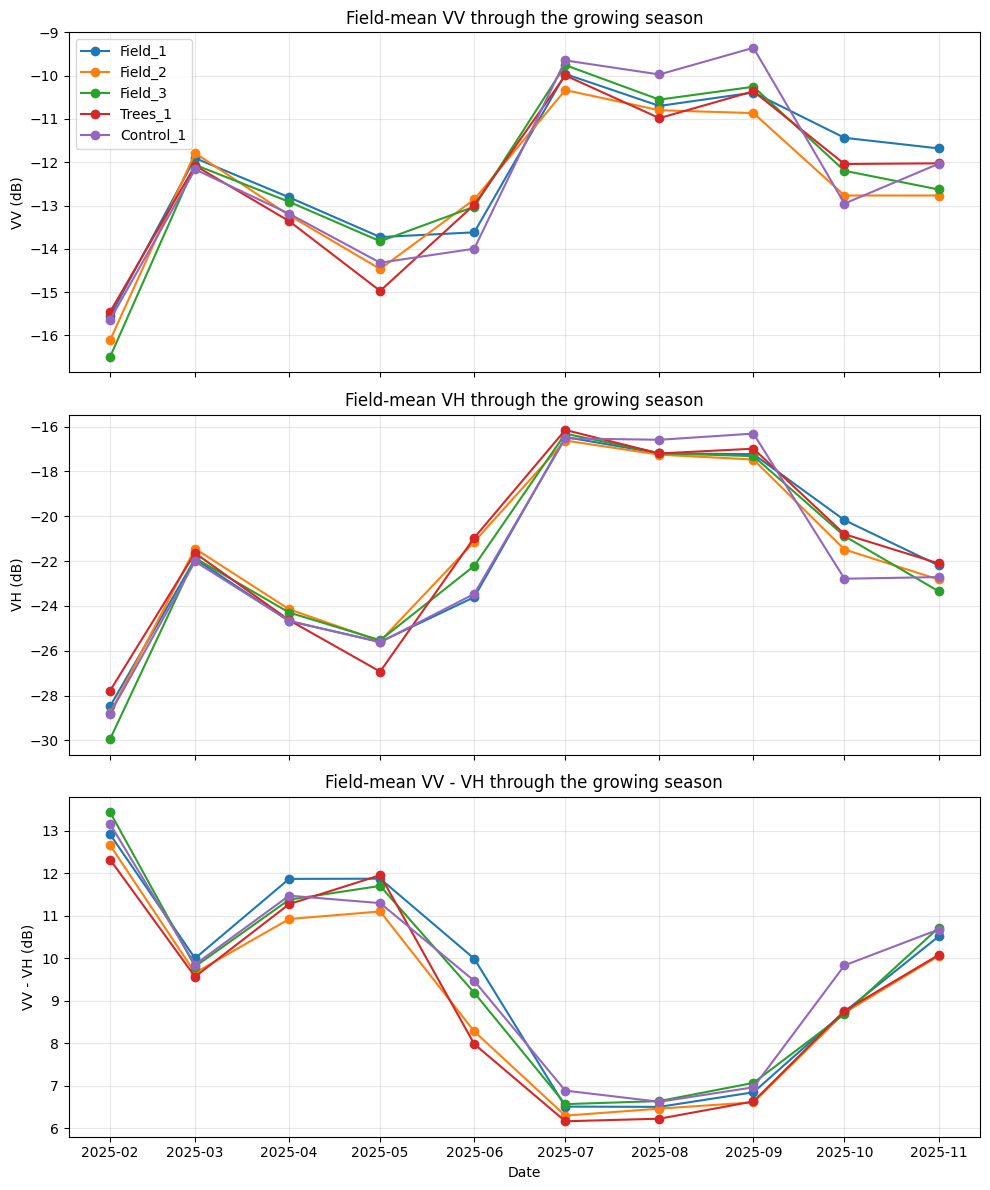

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.



In [23]:
##YOUR CODE HERE (50pts)
import pandas as pd

results = []

for name, df in ts_dict.items():
    peak_vh = df["VH"].max()
    min_vh = df["VH"].min()
    
    growth_metric = peak_vh - min_vh
    
    results.append({
        "ROI": name, 
        "Peak VH (dB)": peak_vh, 
        "Min VH (dB)": min_vh, 
        "Growth Metric (dB)": growth_metric
    })

metric_df = pd.DataFrame(results)
metric_df = metric_df.set_index("ROI")

print("Crop Growth Metric: Maximum Seasonal VH Amplitude")
print("Higher metric values indicate massive vegetative growth (typical for row crops).\n")

metric_df

Crop Growth Metric: Maximum Seasonal VH Amplitude
Higher metric values indicate massive vegetative growth (typical for row crops).



,Peak VH (dB),Min VH (dB),Growth Metric (dB)
ROI,,,
Field_1,-16.466721,-28.475619,12.008898
Field_2,-16.625379,-28.775579,12.150200
Field_3,-16.319766,-29.937890,13.618124
Trees_1,-16.154008,-27.781672,11.627664
Control_1,-16.315396,-28.800222,12.484826


The growth metric successfully calculated the maximum seasonal VH amplitude (Peak VH - Min VH). As expected, the crop fields (Field_1, Field_2, Field_3) show massive growth metrics (>12 dB), which is highly consistent with the massive volume scattering caused by summer crop canopy development.

However, Trees_1 and Control_1 also show unexpectedly high metrics (11.6 dB and 12.4 dB). Since I used the fallback coordinates provided in the notebook instead of manually drawn polygons, it is highly likely that these specific fallback coordinates inadvertently intersected with active agricultural fields or other dense seasonal vegetation. In a perfect scenario with accurately drawn polygons, a true built-up control area (town) would have a metric much closer to 0 dB due to its stable, year-round backscatter profile.

## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [24]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
